# UK Geographic Customer Opportunity Segmentation

## 1. Setup

This notebook performs basic exploratory analysis on the demographic dataset prepared for clustering.

Goals:
- Confirm dataset integrity and clustering feature availability.
- Understand feature distributions and skew.
- Check missingness, correlation structure, and outlier risk.
- Prepare a clean modelling input table for the clustering notebook.

### 1.1 Environment setup and file paths

This cell imports libraries, sets display options, and defines canonical input paths used throughout the notebook.

In [1]:
# Core path utilities and analysis libraries.
from pathlib import Path

# Numerical and tabular processing.
import numpy as np
import pandas as pd
# Basic plotting for quick EDA charts.
import matplotlib.pyplot as plt

# PCA is used for a quick dimensionality/readiness diagnostic.
from sklearn.decomposition import PCA
# StandardScaler is required before distance-based clustering methods such as KMeans.
from sklearn.preprocessing import StandardScaler

# Widen notebook display so profiling tables are easy to inspect.
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 200)

# Resolve repository root whether notebook is run from repo root or notebooks/.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

# Canonical processed-data inputs produced by notebook 1.
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_PATH = DATA_PROCESSED_DIR / "msoa_demographic_features.csv"
DICTIONARY_PATH = DATA_PROCESSED_DIR / "msoa_demographic_features_data_dictionary.csv"

# Quick visual check that file paths resolve correctly.
FEATURES_PATH, DICTIONARY_PATH

(PosixPath('/Users/ChanB01/GitHub/uk-demographic-clustering/data/processed/msoa_demographic_features.csv'),
 PosixPath('/Users/ChanB01/GitHub/uk-demographic-clustering/data/processed/msoa_demographic_features_data_dictionary.csv'))

### 1.2 Load prepared datasets and run initial audit

This cell loads the processed features and checks row/column counts plus geography key uniqueness.

In [2]:
# Load cleaned feature table and companion data dictionary.
msoa_features = pd.read_csv(FEATURES_PATH)
feature_dictionary = pd.read_csv(DICTIONARY_PATH)

# Basic integrity checks for row/column counts and unique geography keys.
dataset_audit = {
    "rows": len(msoa_features),
    "columns": len(msoa_features.columns),
    "unique_geo_codes": msoa_features["geo_code"].nunique(),
    "duplicate_geo_codes": msoa_features["geo_code"].duplicated().sum(),
}

dataset_audit_df = pd.DataFrame([dataset_audit])
display(dataset_audit_df)

# Quick insight summary for skimming.
if dataset_audit["duplicate_geo_codes"] == 0 and dataset_audit["rows"] == dataset_audit["unique_geo_codes"]:
    print("Insight: Dataset key integrity looks good (one row per MSOA, no duplicate geo_code values).")
else:
    print("Insight: Key integrity issue detected. Review duplicate or missing geography keys before clustering.")

,rows,columns,unique_geo_codes,duplicate_geo_codes
0,7264,32,7264,0


Insight: Dataset key integrity looks good (one row per MSOA, no duplicate geo_code values).


## 2. Basic Check

Use demand-side public demographic features only.

Location fields (latitude/longitude, centroid easting/northing) are excluded from clustering so the segments represent customer demand rather than geography.

### 2.1 Confirm approved clustering features

This cell validates that all scope-approved demand-side features exist before analysis continues.

In [3]:
# Exact demand-side feature list agreed in revised project scope.
clustering_features = [
    "total_population",
    "children_share_0_14",
    "young_adult_share_15_24",
    "core_family_adult_share_25_44",
    "midlife_adult_share_45_64",
    "older_adult_share_65_plus",
    "family_household_share",
    "deprived_household_share",
    "car_access_household_share",
    "population_density_per_sq_km",
    "ab_c1_social_grade_share",
]

# Fail early if any expected modelling column is missing.
missing_required = sorted(set(clustering_features) - set(msoa_features.columns))
assert not missing_required, f"Missing expected clustering columns: {missing_required}"

# Keep geography identifiers with modelling features for traceability.
cluster_input = msoa_features[["geo_code", "geo_name", "country"] + clustering_features].copy()
cluster_input.head()

,geo_code,geo_name,country,total_population,children_share_0_14,young_adult_share_15_24,core_family_adult_share_25_44,midlife_adult_share_45_64,older_adult_share_65_plus,family_household_share,deprived_household_share,car_access_household_share,population_density_per_sq_km,ab_c1_social_grade_share
0,E02000001,City of London 001,England,8580,0.063636,0.137646,0.406527,0.251632,0.140559,0.087673,0.402320,0.227967,2975.0,0.840514
1,E02000002,Barking and Dagenham 001,England,8286,0.262129,0.124065,0.292783,0.208907,0.112117,0.470219,0.667596,0.681533,3831.0,0.410756
2,E02000003,Barking and Dagenham 002,England,11539,0.221856,0.125747,0.316579,0.225669,0.110148,0.422284,0.580407,0.705852,5389.7,0.473847
3,E02000004,Barking and Dagenham 003,England,6638,0.186502,0.122778,0.289093,0.251130,0.150497,0.361628,0.560849,0.764400,2663.6,0.508069
4,E02000005,Barking and Dagenham 004,England,11082,0.264844,0.122270,0.316098,0.217109,0.079679,0.497381,0.574656,0.719956,9327.5,0.461278


### 2.2 Missingness and constant-feature checks

This cell converts modelling fields to numeric and reports null rates plus zero-variance feature risks.

In [4]:
# Ensure numeric dtype for all modelling columns.
for col in clustering_features:
    cluster_input[col] = pd.to_numeric(cluster_input[col], errors="coerce")

# Missingness profile helps decide if imputation is required before clustering.
missingness = (
    cluster_input[clustering_features]
    .isna()
    .sum()
    .reset_index(name="missing_rows")
    .rename(columns={"index": "feature"})
)
missingness["missing_share"] = missingness["missing_rows"] / len(cluster_input)
missingness_sorted = missingness.sort_values("missing_share", ascending=False)

# Constant features add no signal and should be removed if present.
constant_features = [
    col for col in clustering_features
    if cluster_input[col].nunique(dropna=True) <= 1
]

print(f"Rows in clustering input: {len(cluster_input):,}")
print(f"Total missing feature values: {int(missingness['missing_rows'].sum()):,}")
print(f"Constant features: {constant_features if constant_features else 'None'}")

top_missing = missingness_sorted.iloc[0]
if top_missing["missing_rows"] == 0 and not constant_features:
    print("Insight: No missing values and no constant features detected. Data is ready for direct scaling/clustering.")
else:
    print(
        "Insight: Highest missing feature is "
        f"{top_missing['feature']} ({top_missing['missing_share']:.2%} missing). "
        "Consider imputation or row filtering before clustering."
    )

# Highest missing-share features first for rapid review.
missingness_sorted

Rows in clustering input: 7,264
Total missing feature values: 0
Constant features: None
Insight: No missing values and no constant features detected. Data is ready for direct scaling/clustering.


,feature,missing_rows,missing_share
0,total_population,0,0.0
1,children_share_0_14,0,0.0
2,young_adult_share_15_24,0,0.0
3,core_family_adult_share_25_44,0,0.0
4,midlife_adult_share_45_64,0,0.0
5,older_adult_share_65_plus,0,0.0
6,family_household_share,0,0.0
7,deprived_household_share,0,0.0
8,car_access_household_share,0,0.0
9,population_density_per_sq_km,0,0.0


### 2.3 Distribution summary statistics

This cell profiles central tendency, spread, and tail behaviour using extended quantiles.

In [5]:
# Descriptive statistics with selected quantiles for clustering diagnostics.
desc = cluster_input[clustering_features].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
desc_view = desc[["count", "mean", "std", "min", "1%", "5%", "25%", "50%", "75%", "95%", "99%", "max"]]
display(desc_view)

# Quantiles highlight skew and long tails that can influence centroid-based methods.
tail_ratio = (desc["99%"] / desc["50%"].replace(0, np.nan)).sort_values(ascending=False)
top_tail_feature = tail_ratio.index[0]
top_tail_ratio = tail_ratio.iloc[0]
print(
    "Insight: Strongest upper-tail stretch appears in "
    f"{top_tail_feature} (99th percentile is {top_tail_ratio:.2f}x the median)."
    " This feature may dominate distance metrics if not scaled or transformed."
)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
total_population,7264.0,8204.482792,1815.668163,2055.000000,5295.150000,5756.000000,6827.000000,7955.500000,9289.250000,11625.700000,13298.740000,18478.000000
children_share_0_14,7264.0,0.172368,0.035719,0.014016,0.078014,0.119784,0.150939,0.170559,0.192168,0.233792,0.265944,0.368466
young_adult_share_15_24,7264.0,0.114822,0.055603,0.048405,0.072038,0.080431,0.092798,0.102599,0.116907,0.177577,0.411931,0.782135
core_family_adult_share_25_44,7264.0,0.261434,0.064110,0.093444,0.149787,0.172394,0.218454,0.254522,0.293374,0.379664,0.464508,0.618401
midlife_adult_share_45_64,7264.0,0.260895,0.037918,0.040125,0.130178,0.191184,0.243045,0.266225,0.285215,0.311646,0.328778,0.353829
older_adult_share_65_plus,7264.0,0.190481,0.070939,0.008499,0.049134,0.079190,0.137559,0.190479,0.238335,0.305967,0.365308,0.528791
family_household_share,7264.0,0.285558,0.066526,0.024283,0.126704,0.187319,0.244764,0.280012,0.321253,0.402363,0.479222,0.607085
deprived_household_share,7264.0,0.517871,0.088400,0.270893,0.343943,0.383483,0.451290,0.510902,0.581297,0.668561,0.725545,0.786902
car_access_household_share,7264.0,0.770087,0.143715,0.179562,0.321398,0.467457,0.699632,0.805492,0.880381,0.929217,0.945001,0.972030
population_density_per_sq_km,7264.0,3421.895237,3624.561918,5.400000,30.063000,72.915000,688.225000,2570.000000,4664.100000,10945.540000,17337.529000,23873.400000


Insight: Strongest upper-tail stretch appears in population_density_per_sq_km (99th percentile is 6.75x the median). This feature may dominate distance metrics if not scaled or transformed.


## 3. EDA

### 3.1 Feature distribution histograms

This cell provides a visual scan for skew, heavy tails, truncation, and unusual shape differences across variables.

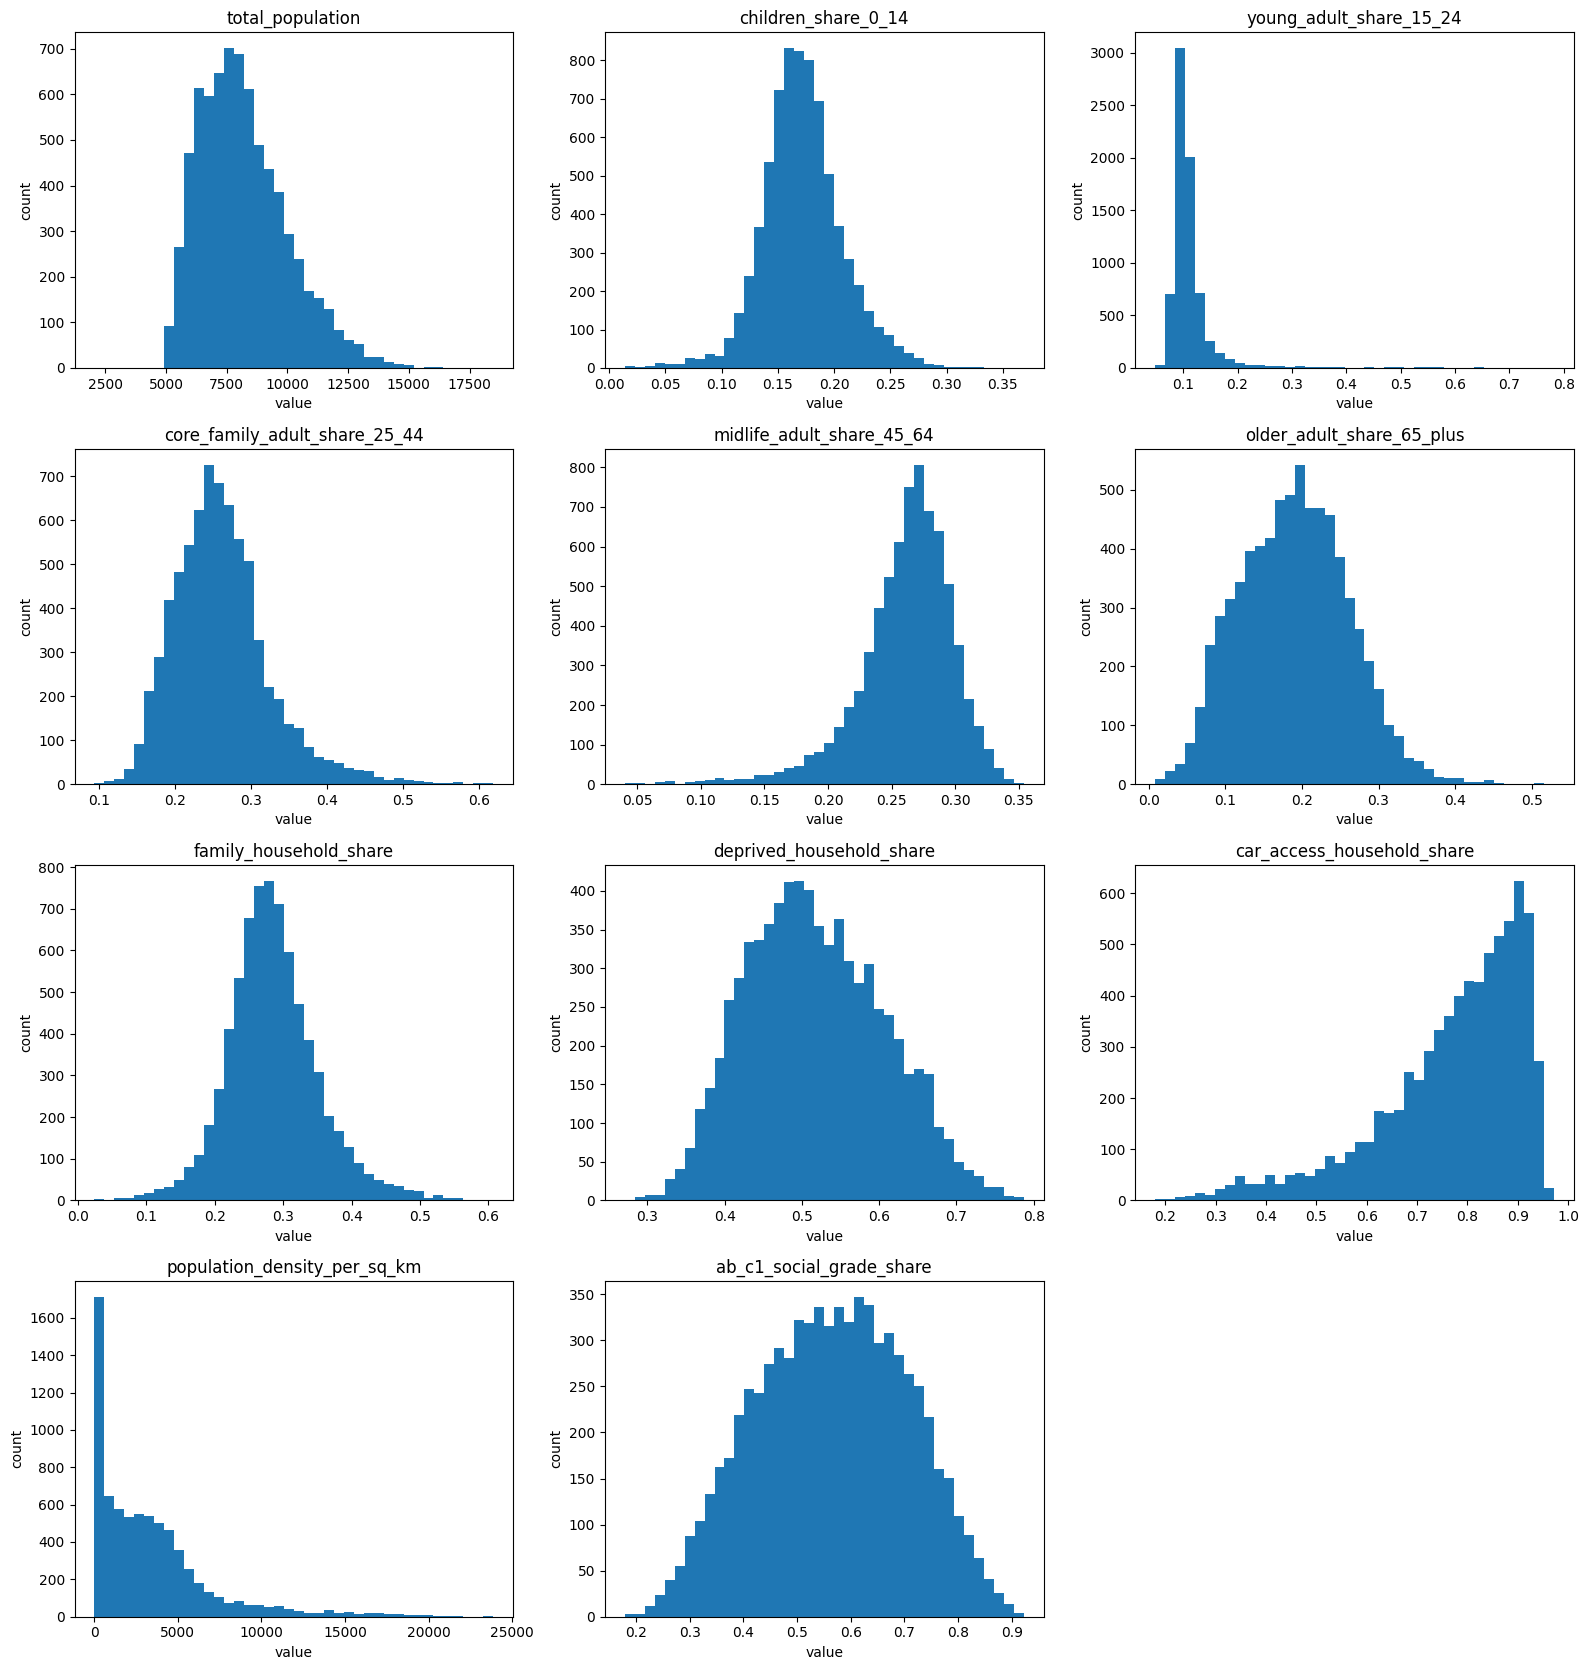

In [6]:
# Distribution plots (quick scan for skew, truncation, and unusual tails).
plot_cols = clustering_features
n_cols = 3
# Compute rows dynamically so all features render even if list changes.
n_rows = int(np.ceil(len(plot_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.2 * n_rows))
axes = np.array(axes).reshape(-1)

for ax, col in zip(axes, plot_cols):
    # Drop missing values per feature to avoid plotting errors.
    series = cluster_input[col].dropna()
    ax.hist(series, bins=40)
    ax.set_title(col)
    ax.set_xlabel("value")
    ax.set_ylabel("count")

# Hide any extra subplot slots when feature count is not a multiple of n_cols.
for ax in axes[len(plot_cols):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### 3.2 Correlation analysis and redundancy check

This cell shows the correlation heatmap and lists strongly correlated feature pairs for potential pruning decisions.

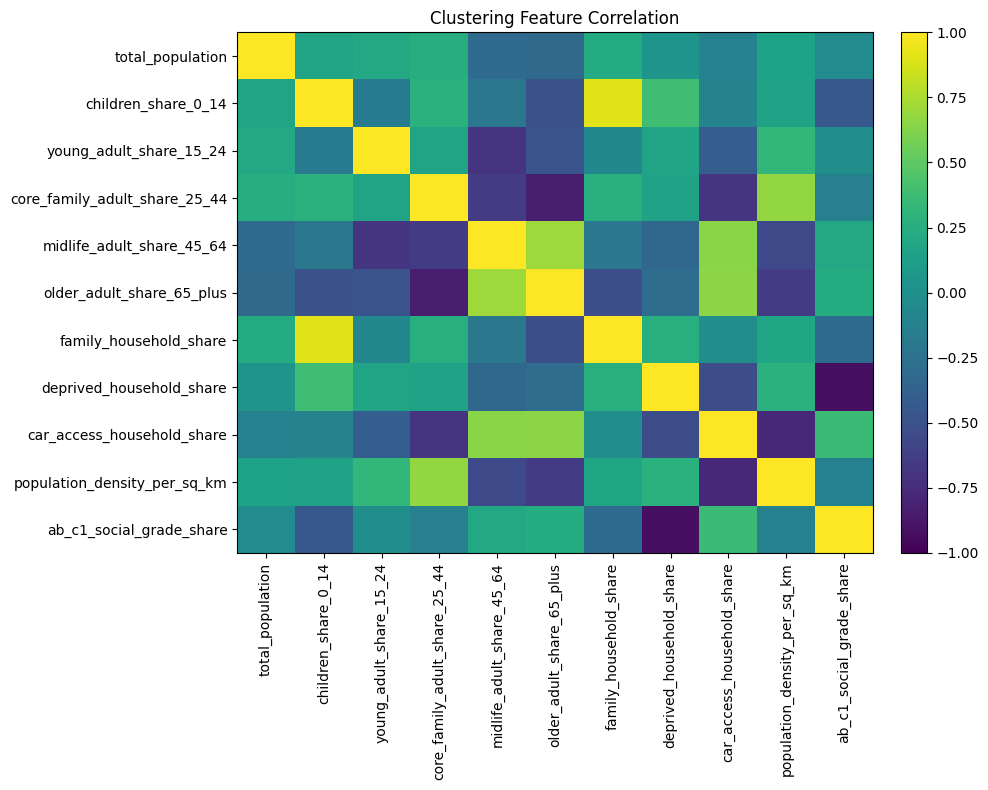

,feature_1,feature_2,correlation
3,deprived_household_share,ab_c1_social_grade_share,-0.915608
0,children_share_0_14,family_household_share,0.913128
1,core_family_adult_share_25_44,older_adult_share_65_plus,-0.828662
4,car_access_household_share,population_density_per_sq_km,-0.769714
2,midlife_adult_share_45_64,older_adult_share_65_plus,0.706450


Insight: Highest collinearity pair is deprived_household_share vs ab_c1_social_grade_share (r = -0.92). Review whether both variables are needed in clustering.


In [7]:
# Correlation matrix to identify redundant information across inputs.
corr = cluster_input[clustering_features].corr(numeric_only=True)

# Heatmap gives a fast visual read of positive/negative linear relationships.
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr.values, interpolation="nearest", aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index)
ax.set_title("Clustering Feature Correlation")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

# Extract strongly correlated feature pairs to support feature-pruning decisions.
high_corr_pairs = []
threshold = 0.7
for i, col_i in enumerate(corr.columns):
    for j, col_j in enumerate(corr.columns):
        if j <= i:
            continue
        value = corr.iloc[i, j]
        if abs(value) >= threshold:
            high_corr_pairs.append((col_i, col_j, value))

# Sort by absolute correlation so strongest relationships appear first.
corr_pairs_df = pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "correlation"]).sort_values(
    "correlation", key=np.abs, ascending=False
)
display(corr_pairs_df)

if corr_pairs_df.empty:
    print("Insight: No feature pairs exceed the |0.80| threshold, so redundancy risk is limited.")
else:
    strongest = corr_pairs_df.iloc[0]
    print(
        "Insight: Highest collinearity pair is "
        f"{strongest['feature_1']} vs {strongest['feature_2']} "
        f"(r = {strongest['correlation']:.2f}). "
        "Review whether both variables are needed in clustering."
    )

### 3.3 Outlier screening by feature

This cell applies an IQR-based rule to flag potential outlier-heavy variables before clustering.

In [8]:
# IQR-based outlier counts for a quick robustness check.
outlier_rows = []
for col in clustering_features:
    # Tukey fences flag values outside the typical interquartile spread.
    q1 = cluster_input[col].quantile(0.25)
    q3 = cluster_input[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (cluster_input[col] < lower) | (cluster_input[col] > upper)
    outlier_rows.append({
        "feature": col,
        "outlier_count": int(mask.sum()),
        "outlier_share": float(mask.mean()),
        "lower_bound": lower,
        "upper_bound": upper,
    })

# Features with higher outlier share may need winsorisation or transformation later.
outlier_df = pd.DataFrame(outlier_rows).sort_values("outlier_share", ascending=False)
display(outlier_df)

top_outlier = outlier_df.iloc[0]
print(
    "Insight: Most outlier-heavy feature is "
    f"{top_outlier['feature']} ({top_outlier['outlier_share']:.2%} flagged by IQR rule). "
    "Consider robust scaling or transformation sensitivity checks."
    )

,feature,outlier_count,outlier_share,lower_bound,upper_bound
2,young_adult_share_15_24,570,0.078469,0.056635,0.153070
9,population_density_per_sq_km,393,0.054102,-5275.587500,10627.912500
8,car_access_household_share,279,0.038409,0.428508,1.151505
6,family_household_share,271,0.037307,0.130030,0.435986
1,children_share_0_14,262,0.036068,0.089096,0.254011
4,midlife_adult_share_45_64,258,0.035518,0.179791,0.348469
3,core_family_adult_share_25_44,240,0.033040,0.106072,0.405756
0,total_population,106,0.014593,3133.625000,12982.625000
5,older_adult_share_65_plus,37,0.005094,-0.013604,0.389498
7,deprived_household_share,5,0.000688,0.256279,0.776307


Insight: Most outlier-heavy feature is young_adult_share_15_24 (7.85% flagged by IQR rule). Consider robust scaling or transformation sensitivity checks.


## 4. Pre-Clustering Check

### 4.1 Standardisation check

KMeans is scale-sensitive, so this step checks that scaled features have mean near 0 and standard deviation near 1.

In [9]:
# Keep only complete rows for the initial clustering prototype.
cluster_input_model = cluster_input.dropna(subset=clustering_features).copy()

# Fit scaler on modelling inputs and transform to z-scores.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_input_model[clustering_features])
# Wrap scaled matrix in DataFrame so per-feature checks stay readable.
X_scaled_df = pd.DataFrame(X_scaled, columns=clustering_features, index=cluster_input_model.index)

# Means should be approximately 0 and std approximately 1 after scaling.
scaled_audit = pd.DataFrame({
    "scaled_mean": X_scaled_df.mean(),
    "scaled_std": X_scaled_df.std(ddof=0),
})
display(scaled_audit)

print(f"Rows retained for modelling: {len(cluster_input_model):,} / {len(cluster_input):,}")
max_abs_mean = scaled_audit["scaled_mean"].abs().max()
min_std = scaled_audit["scaled_std"].min()
max_std = scaled_audit["scaled_std"].max()
print(
    "Insight: Scaling looks stable "
    f"(max |mean| = {max_abs_mean:.4f}, std range = {min_std:.4f} to {max_std:.4f})."
    )

,scaled_mean,scaled_std
total_population,3.286651e-16,1.0
children_share_0_14,-2.660623e-16,1.0
young_adult_share_15_24,-1.565072e-17,1.0
core_family_adult_share_25_44,3.130144e-17,1.0
midlife_adult_share_45_64,5.164738e-16,1.0
older_adult_share_65_plus,-3.130144e-17,1.0
family_household_share,5.008231e-16,1.0
deprived_household_share,4.695216e-17,1.0
car_access_household_share,4.069187e-16,1.0
population_density_per_sq_km,-3.130144e-17,1.0


Rows retained for modelling: 7,264 / 7,264
Insight: Scaling looks stable (max |mean| = 0.0000, std range = 1.0000 to 1.0000).


### 4.2 PCA variance concentration check

This cell estimates how many latent dimensions explain most of the structure in the scaled feature space.

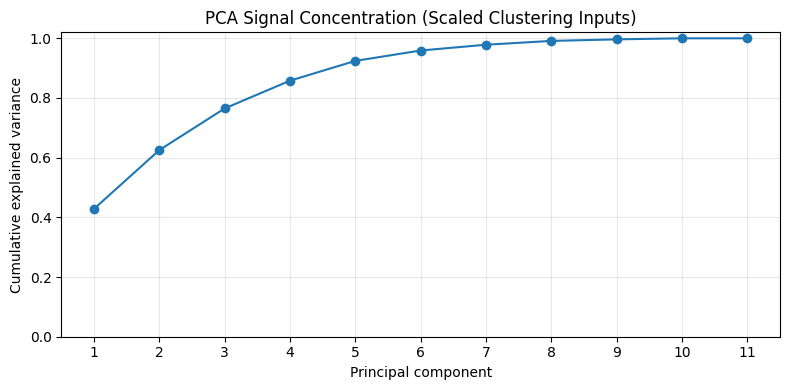

,component,explained_variance_ratio,cumulative_explained_variance
0,1,4.282346e-01,0.428235
1,2,1.970929e-01,0.625327
2,3,1.395870e-01,0.764914
3,4,9.303885e-02,0.857953
4,5,6.634112e-02,0.924294
5,6,3.476600e-02,0.959060
6,7,1.940339e-02,0.978464
7,8,1.276248e-02,0.991226
8,9,5.237389e-03,0.996464
9,10,3.536318e-03,1.000000


Insight: Variance concentration summary -> 80% by PC4, 90% by PC5, 95% by PC6.


In [10]:
# Optional dimensionality check: explained variance from PCA on scaled features.
pca = PCA()
pca.fit(X_scaled)
# Build a compact table for per-component and cumulative explained variance.
explained = pd.DataFrame({
    "component": np.arange(1, len(clustering_features) + 1),
    "explained_variance_ratio": pca.explained_variance_ratio_,
})
explained["cumulative_explained_variance"] = explained["explained_variance_ratio"].cumsum()

# Visualise how quickly information accumulates across principal components.
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(explained["component"], explained["cumulative_explained_variance"], marker="o")
ax.set_xticks(explained["component"])
ax.set_ylim(0, 1.02)
ax.set_xlabel("Principal component")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA Signal Concentration (Scaled Clustering Inputs)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

display(explained)

# Insight helper: minimum number of components needed to cross variance thresholds.
def components_for_threshold(df, threshold):
    reached = df[df["cumulative_explained_variance"] >= threshold]
    if reached.empty:
        return None
    return int(reached["component"].iloc[0])

pc80 = components_for_threshold(explained, 0.80)
pc90 = components_for_threshold(explained, 0.90)
pc95 = components_for_threshold(explained, 0.95)
print(
    "Insight: Variance concentration summary -> "
    f"80% by PC{pc80}, 90% by PC{pc90}, 95% by PC{pc95}."
    )

## 5 Export clustering-ready dataset

### 5.1 Save final input table
This cell writes the cleaned, scope-compliant clustering input CSV for notebook 3.

In [11]:
# Save a ready-to-use input table for clustering notebook 3.
# Use a reduced feature set to avoid double-weighting highly correlated pairs from section 3.2:
# - Keep ab_c1_social_grade_share, drop deprived_household_share
# - Keep children_share_0_14, drop family_household_share
selected_clustering_features = [
    "total_population",
    "children_share_0_14",
    "young_adult_share_15_24",
    "core_family_adult_share_25_44",
    "midlife_adult_share_45_64",
    "older_adult_share_65_plus",
    "car_access_household_share",
    "population_density_per_sq_km",
    "ab_c1_social_grade_share",
]

# Keep only identifiers plus selected clustering features.
output_cols = ["geo_code", "geo_name", "country"] + selected_clustering_features
cluster_input_output = cluster_input_model[output_cols].copy()

# Persist a clean handoff file so notebook 3 does not need to repeat EDA filtering.
CLUSTER_INPUT_PATH = DATA_PROCESSED_DIR / "msoa_clustering_input.csv"
cluster_input_output.to_csv(CLUSTER_INPUT_PATH, index=False)

print(f"Saved: {CLUSTER_INPUT_PATH.relative_to(PROJECT_ROOT)}")
print(f"Rows: {len(cluster_input_output):,}")
print(f"Columns: {len(cluster_input_output.columns):,}")
print("Selected clustering features:")
print(selected_clustering_features)

Saved: data/processed/msoa_clustering_input.csv
Rows: 7,264
Columns: 12
Selected clustering features:
['total_population', 'children_share_0_14', 'young_adult_share_15_24', 'core_family_adult_share_25_44', 'midlife_adult_share_45_64', 'older_adult_share_65_plus', 'car_access_household_share', 'population_density_per_sq_km', 'ab_c1_social_grade_share']


## 6. Pre-clustering answers from this notebook

1. Missing values / imputation need:
No missing values were found across the clustering features (7,264 rows retained), so no imputation is required for the current dataset.

2. Feature skew and transformation needs:
Population density shows a heavy upper tail (99th percentile is 6.75x median), and young adult share has the highest IQR outlier rate (7.85%). Standardisation is already stable and sufficient for a baseline KMeans run. Optional sensitivity check: try a log transform on population density and compare cluster stability.

3. High correlation handling:
Strong collinearity was observed:
- deprived_household_share vs ab_c1_social_grade_share (r = -0.916)
- children_share_0_14 vs family_household_share (r = 0.913)

For future clustering input in this notebook, we keep:
- ab_c1_social_grade_share and drop deprived_household_share
- children_share_0_14 and drop family_household_share

4. Sample size completeness:
All 7,264 MSOAs are retained after preprocessing and scaling checks.

5. Anything else needed before future clustering?
No additional mandatory data-prep steps are required in this notebook for a baseline clustering run. Optional next step is a sensitivity comparison between this reduced feature set and the full feature set when selecting the final model configuration.